# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/RF'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_holiday', 'tavg', 'prcp',
    'is_after_weekend', 'is_after_holiday', 'is_after_gap',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

TARGET = 'total_tonnes'

# Model Definition - Random Forest

In [6]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def run_rf_prediction(df, dataset_name, dataset_code, dataset_number, features, split_days=90, n_splits=3, TARGET='total_tonnes', VIS_DIR='.'):
    """
    Train Random Forest with rolling-origin validation.
    Uses walk-forward prediction: dynamically updates lag values.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"Random Forest PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # feature filtering
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    # NaN drop
    cols_to_check = [TARGET] + available_features
    df_valid = df.dropna(subset=cols_to_check).reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid (non-NaN in target & features): {len(df_valid)}")


    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []
    total_needed = split_days * n_splits

    if len(df_valid) < total_needed + 100:
        print(f"WARNING: Not enough data for {n_splits} splits of {split_days} days.")
        print(f"Reducing to 2 splits.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each")

    best_smape = float('inf')
    best_split_data = None
    best_model = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days
        if offset == 0:
            train = df_valid.iloc[:-split_days].copy()
            test = df_valid.iloc[-split_days:].copy()
        else:
            train = df_valid.iloc[:-(offset + split_days)].copy()
            test = df_valid.iloc[-(offset + split_days):-offset].copy()

        print(f"\n--- Split {split_idx+1}/{n_splits} ---")
        print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
        print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")

        # model fit
        X_train = train[available_features]
        y_train = train[TARGET]

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        # walk-forward prediction on test set - no negatives
        predictions = []
        test_copy = test.copy()

        for i in range(len(test_copy)):
            row = test_copy.iloc[i:i+1][available_features]
            pred = model.predict(row)[0]
            pred = max(pred, 0)
            predictions.append(pred)

            # update lag features for next predictions
            idx = test_copy.index[i]
            if i + 1 < len(test_copy):
                next_idx = test_copy.index[i + 1]
                if 'lag_1' in available_features:
                    test_copy.loc[next_idx, 'lag_1'] = pred
                if 'lag_2' in available_features and i + 2 < len(test_copy):
                    test_copy.loc[test_copy.index[min(i+2, len(test_copy)-1)], 'lag_2'] = pred

        y_true = test[TARGET].values
        y_pred = np.array(predictions)

        # metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_val = smape(y_true, y_pred)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val})
        print(f"MAE: {mae:.2f}t | RMSE: {rmse:.2f}t | sMAPE: {smape_val:.2f}%")

        # track the best split
        if smape_val < best_smape:
            best_smape = smape_val
            best_model = model
            best_split_data = {
                'split_idx': split_idx + 1,
                'train': train,
                'test': test,
                'y_true': y_true,
                'y_pred': y_pred,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val
            }


    # ============================================================
    # AVERAGE METRICS ACROSS SPLITS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])

    print(f"\n--- AVERAGE ACROSS {n_splits} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    train_plot = best_split_data['train']
    test_plot = best_split_data['test']
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot 4X1: Actual vs Predicted (test period) - Random Forest ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train_plot.iloc[-30:]
    ax.plot(context['date'], context[TARGET], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test_plot['date'], y_true_plot, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test_plot['date'], y_pred_plot, color='red',
            linewidth=1.5, linestyle='--', label='Random Forest Forecast')

    ax.axvline(x=test_plot['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f"Random Forest Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}1_rf_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 4X2: Zoom on first 30 days of test - Random Forest ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, split_days)
    ax.plot(test_plot['date'].iloc[:zoom_days], y_true_plot[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test_plot['date'].iloc[:zoom_days], y_pred_plot[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='Random Forest')

    ax.set_title(f"Random Forest Forecast Zoom — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}2_rf_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 4X3: Feature importance - Random Forest ---
    fig, ax = plt.subplots(figsize=(10, 8))

    importance = pd.Series(best_model.feature_importances_, index=available_features)
    importance = importance.sort_values(ascending=True)
    importance.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

    ax.set_title(f"Top 15 Feature Importance — {dataset_name} (Best Model)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}3_rf_feature_importance_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'Random Forest',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': n_splits,
        'split_days': split_days,
        'split_details': split_results
    }

# Model Prediction - Random Forest


Random Forest PREDICTION — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid (non-NaN in target & features): 2100

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1830 days (2012-01-31 → 2017-12-31)
Test:  90 days (2018-01-01 → 2018-05-22)
MAE: 6.45t | RMSE: 8.09t | sMAPE: 25.62%

--- Split 2/3 ---
Train: 1920 days (2012-01-31 → 2018-05-22)
Test:  90 days (2018-05-23 → 2018-09-16)
MAE: 6.35t | RMSE: 8.49t | sMAPE: 25.28%

--- Split 3/3 ---
Train: 2010 days (2012-01-31 → 2018-09-16)
Test:  90 days (2018-09-17 → 2018-12-30)
MAE: 6.30t | RMSE: 8.60t | sMAPE: 24.76%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   6.37 tonnes
RMSE:  8.39 tonnes
sMAPE: 25.22%
Best split was Split 3 (sMAPE: 24.76%)


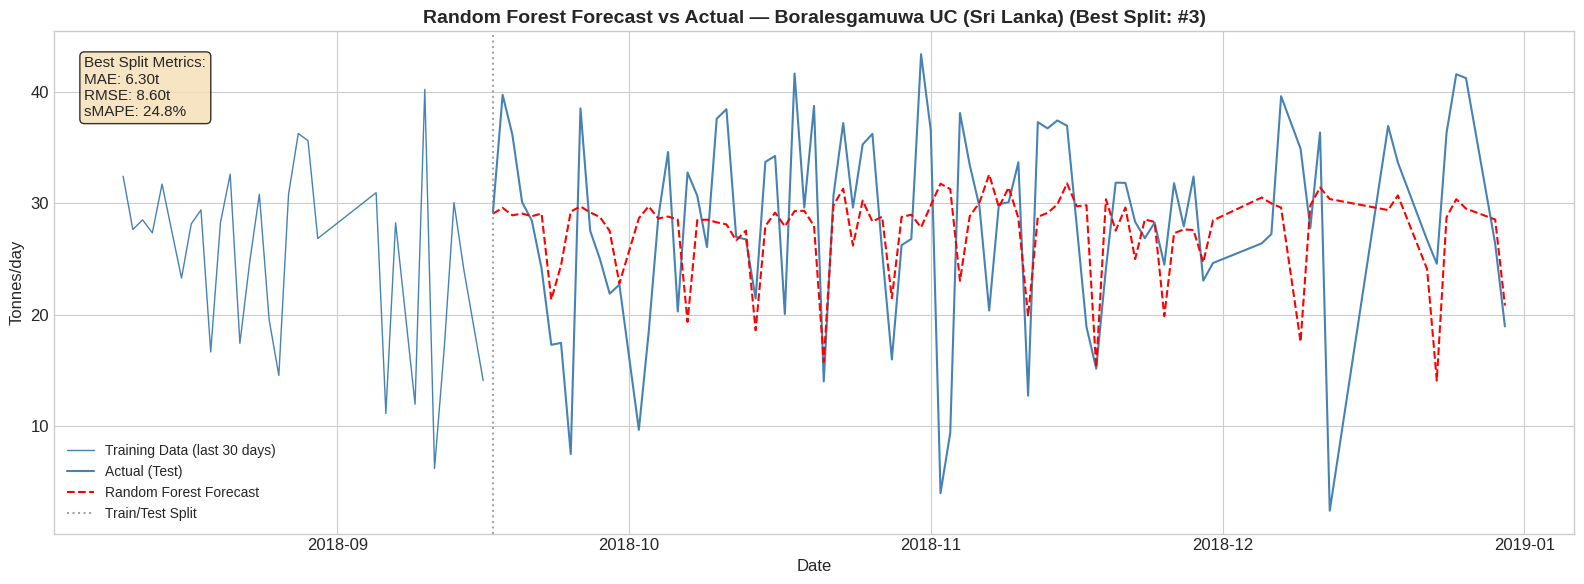

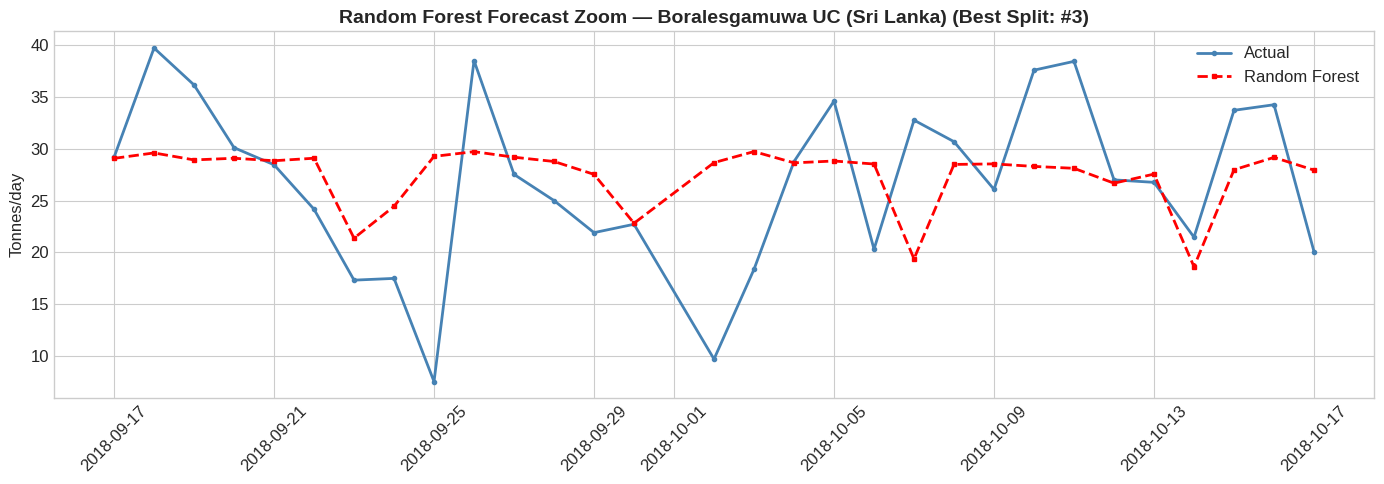

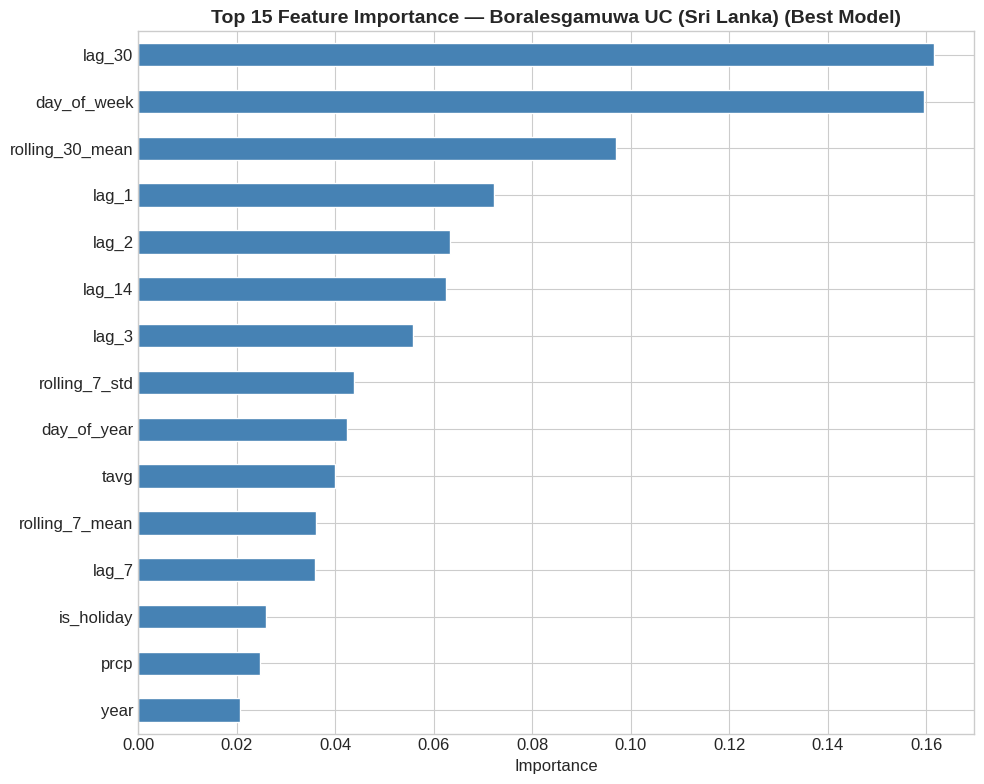


Random Forest PREDICTION — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid (non-NaN in target & features): 1323

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 1053 days (2012-01-31 → 2015-02-16)
Test:  90 days (2015-02-17 → 2015-06-19)
MAE: 19.14t | RMSE: 26.21t | sMAPE: 13.48%

--- Split 2/3 ---
Train: 1143 days (2012-01-31 → 2015-06-19)
Test:  90 days (2015-06-20 → 2015-09-17)
MAE: 36.08t | RMSE: 47.95t | sMAPE: 28.59%

--- Split 3/3 ---
Train: 1233 days (2012-01-31 → 2015-09-17)
Test:  90 days (2015-09-18 → 2015-12-31)
MAE: 29.75t | RMSE: 42.81t | sMAPE: 24.81%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   28.32 tonnes
RMSE:  38.99 tonnes
sMAPE: 22.29%
Best split was Split 1 (sMAPE: 13.48%)


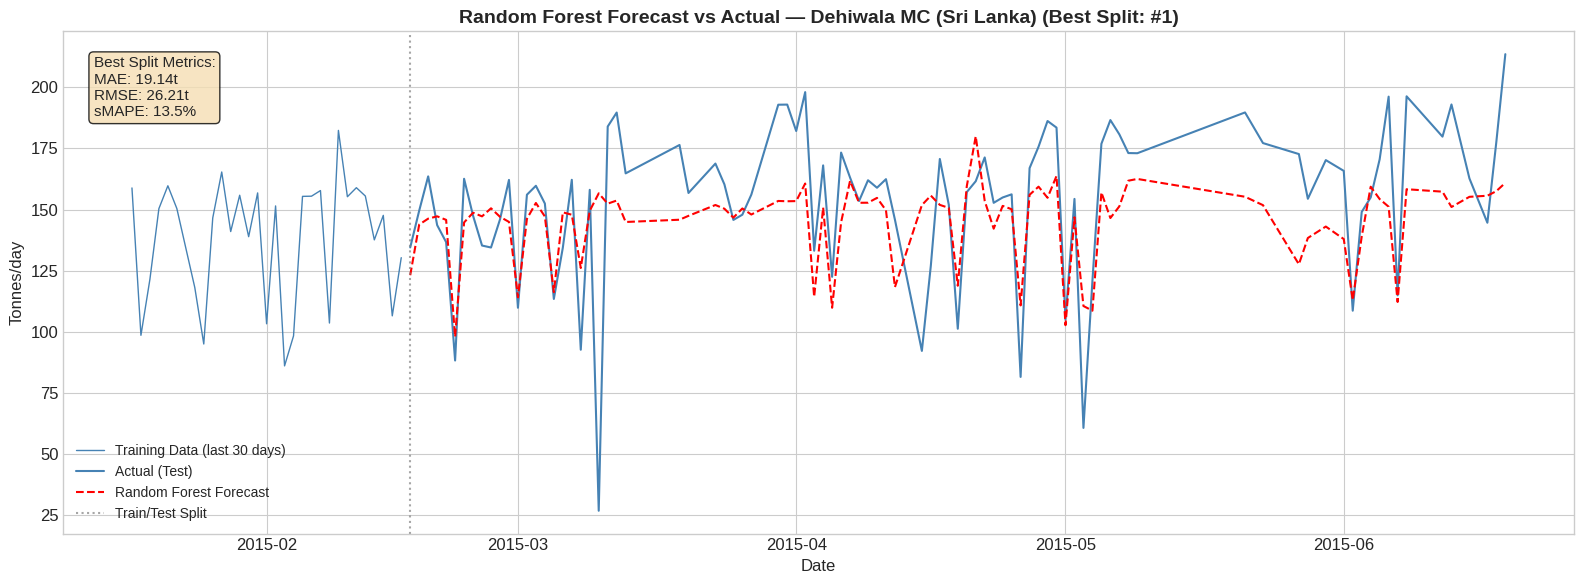

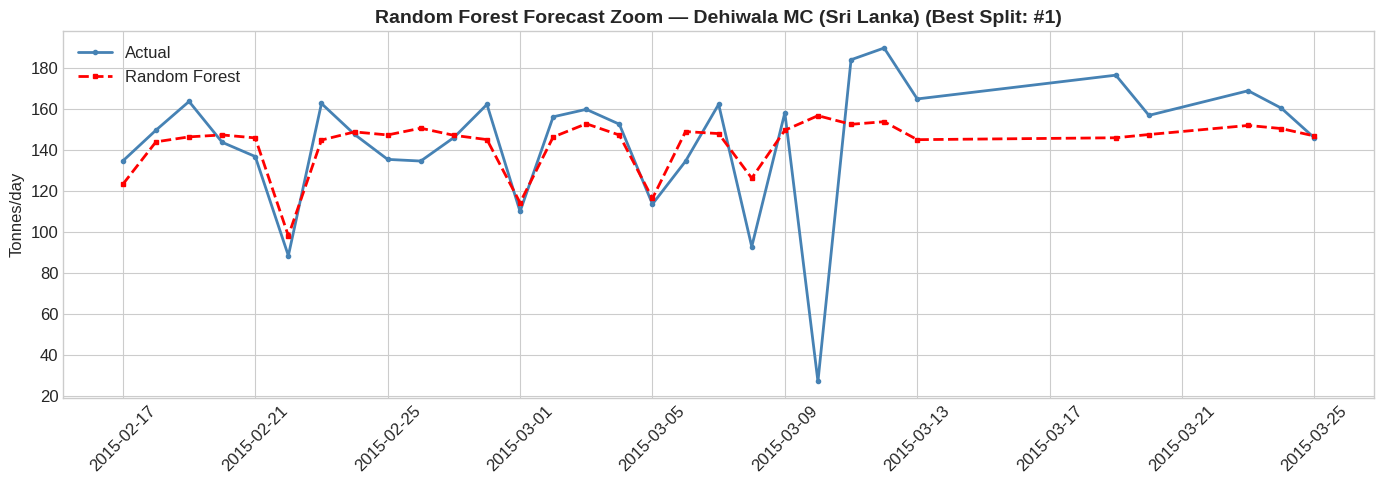

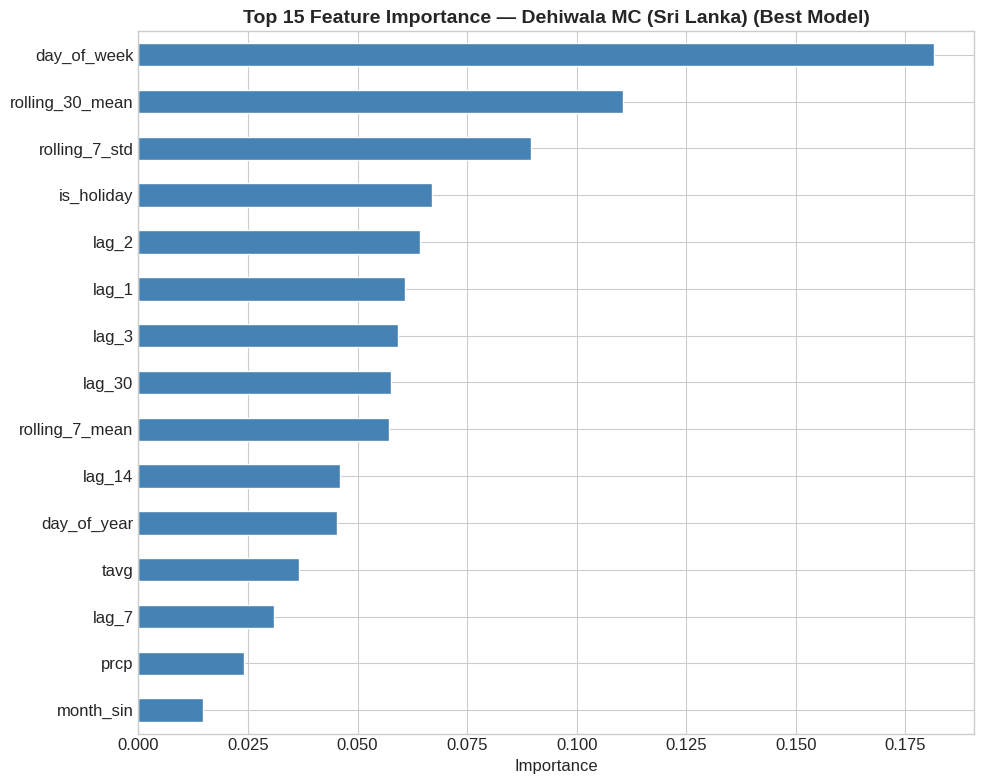


Random Forest PREDICTION — Homagama PS (Sri Lanka)
Total rows: 2526, Valid (non-NaN in target & features): 852

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 582 days (2012-02-22 → 2017-11-20)
Test:  90 days (2017-11-21 → 2018-04-25)
MAE: 9.68t | RMSE: 12.25t | sMAPE: 32.02%

--- Split 2/3 ---
Train: 672 days (2012-02-22 → 2018-04-25)
Test:  90 days (2018-04-27 → 2018-09-06)
MAE: 12.19t | RMSE: 15.81t | sMAPE: 34.60%

--- Split 3/3 ---
Train: 762 days (2012-02-22 → 2018-09-06)
Test:  90 days (2018-09-07 → 2018-12-31)
MAE: 11.47t | RMSE: 14.96t | sMAPE: 34.47%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   11.11 tonnes
RMSE:  14.34 tonnes
sMAPE: 33.69%
Best split was Split 1 (sMAPE: 32.02%)


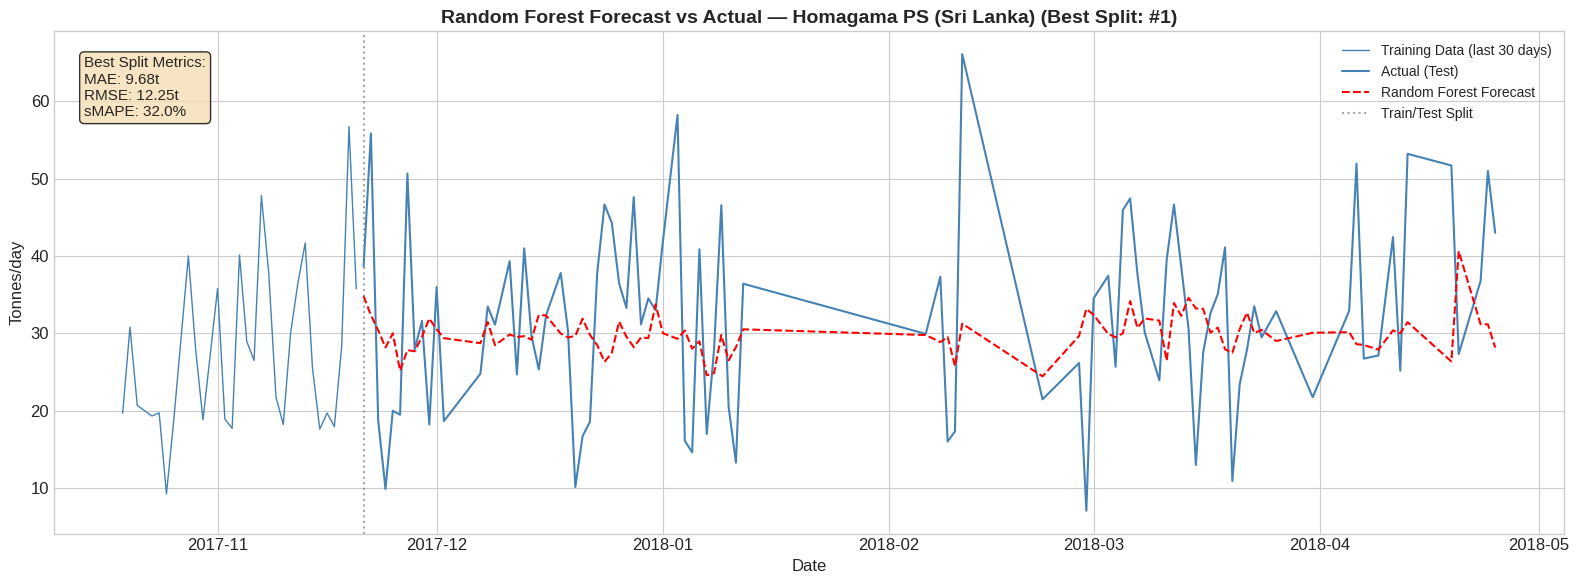

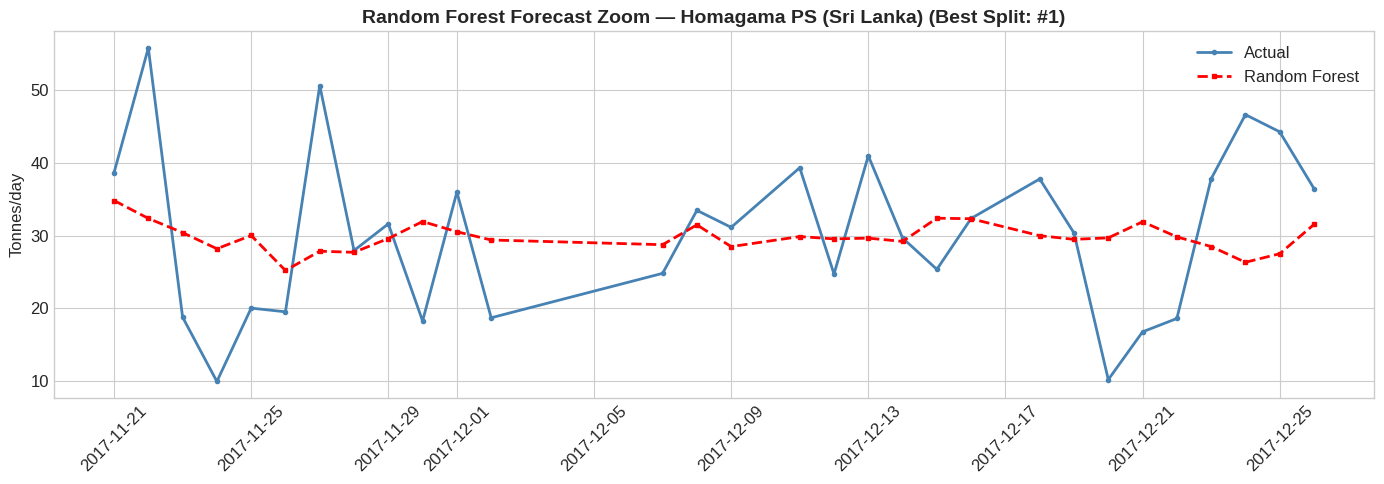

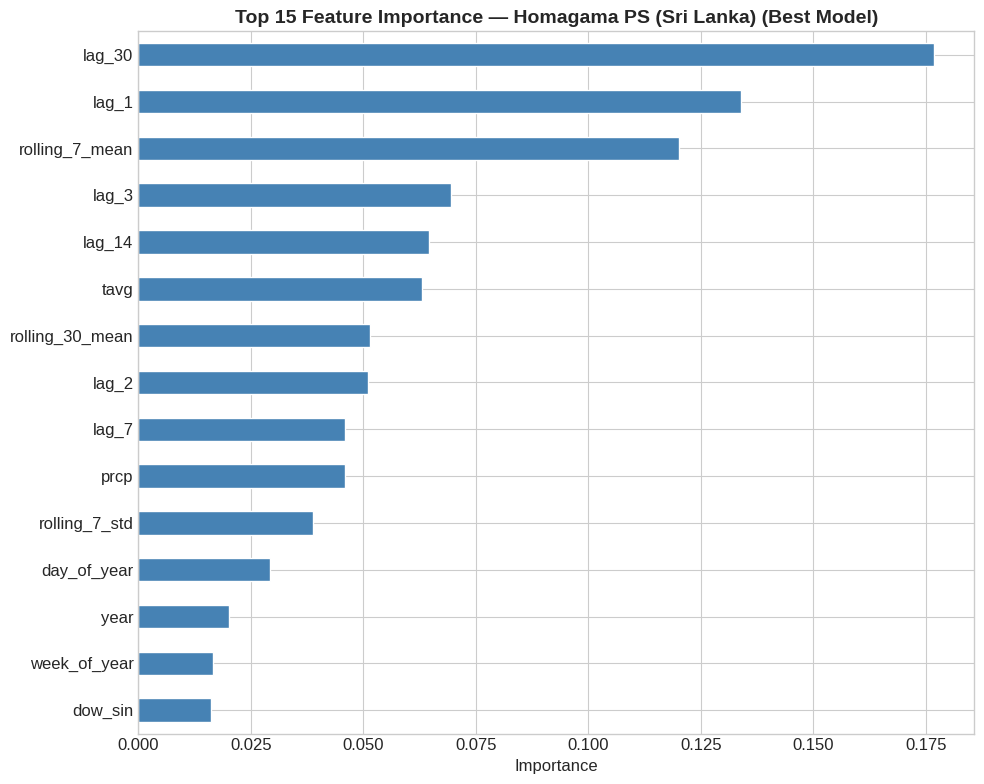


Random Forest PREDICTION — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid (non-NaN in target & features): 982

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 712 days (2015-01-31 → 2017-10-25)
Test:  90 days (2017-10-26 → 2018-02-27)
MAE: 13.37t | RMSE: 18.96t | sMAPE: 18.97%

--- Split 2/3 ---
Train: 802 days (2015-01-31 → 2018-02-27)
Test:  90 days (2018-02-28 → 2018-07-24)
MAE: 18.37t | RMSE: 23.50t | sMAPE: 26.96%

--- Split 3/3 ---
Train: 892 days (2015-01-31 → 2018-07-24)
Test:  90 days (2018-07-29 → 2018-12-11)
MAE: 19.18t | RMSE: 25.08t | sMAPE: 28.72%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   16.97 tonnes
RMSE:  22.51 tonnes
sMAPE: 24.88%
Best split was Split 1 (sMAPE: 18.97%)


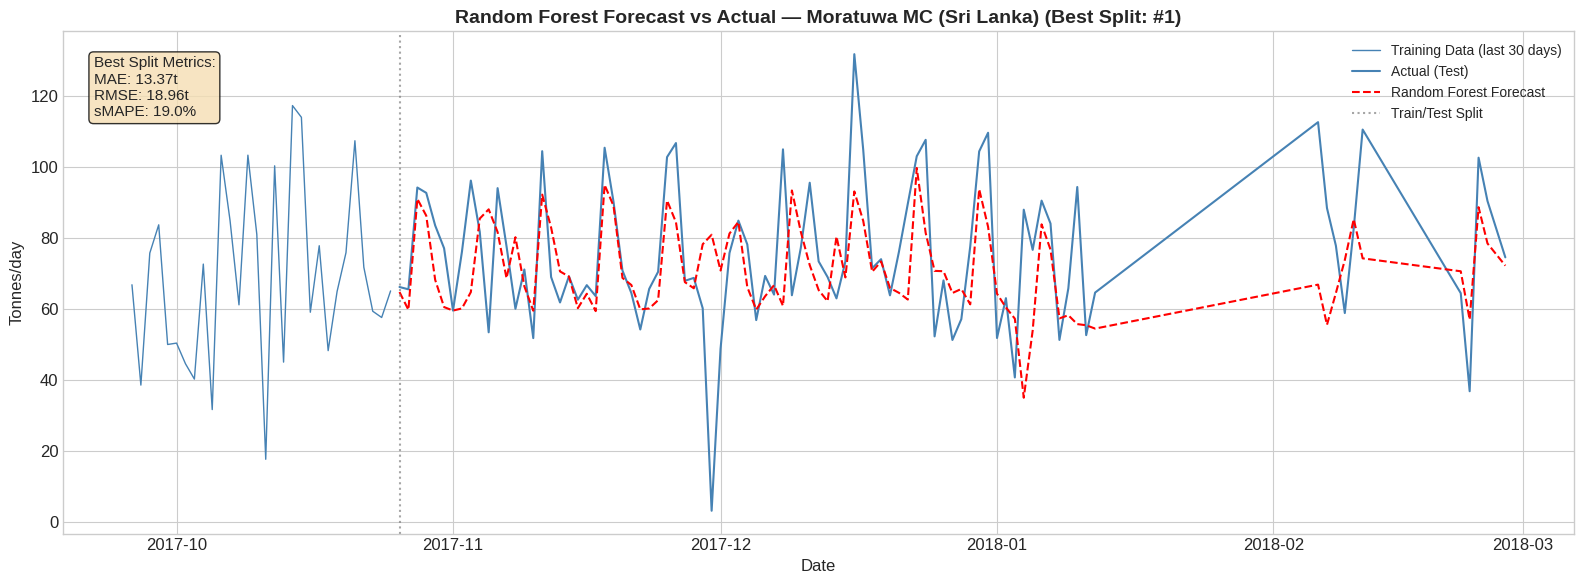

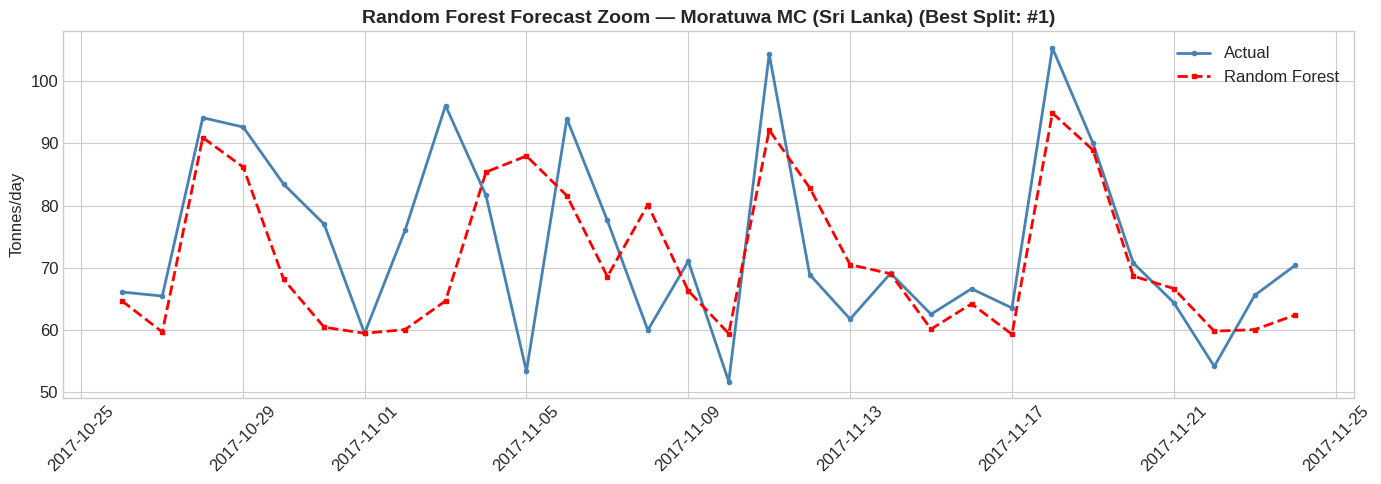

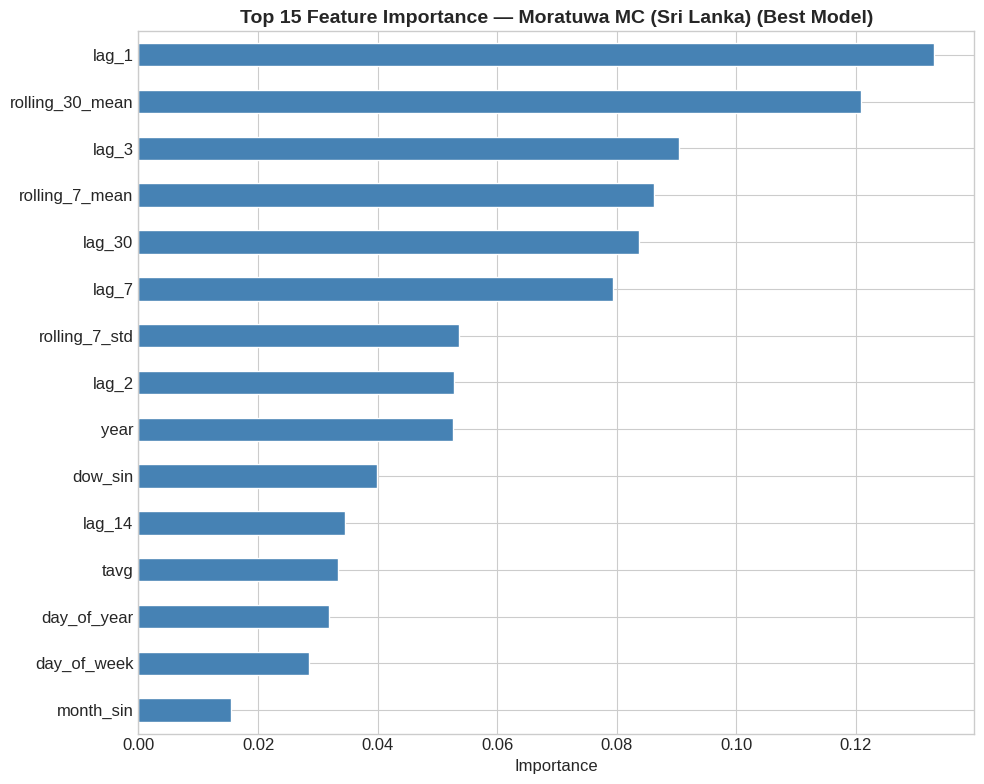


Random Forest PREDICTION — Austin TX (USA)
Total rows: 5813, Valid (non-NaN in target & features): 5749

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 5479 days (2005-02-01 → 2020-04-01)
Test:  90 days (2020-04-02 → 2020-06-30)
MAE: 122.16t | RMSE: 177.72t | sMAPE: 50.13%

--- Split 2/3 ---
Train: 5569 days (2005-02-01 → 2020-06-30)
Test:  90 days (2020-07-01 → 2020-09-28)
MAE: 76.30t | RMSE: 109.87t | sMAPE: 42.86%

--- Split 3/3 ---
Train: 5659 days (2005-02-01 → 2020-09-28)
Test:  90 days (2020-09-29 → 2020-12-31)
MAE: 176.45t | RMSE: 370.36t | sMAPE: 43.46%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   124.97 tonnes
RMSE:  219.32 tonnes
sMAPE: 45.48%
Best split was Split 2 (sMAPE: 42.86%)


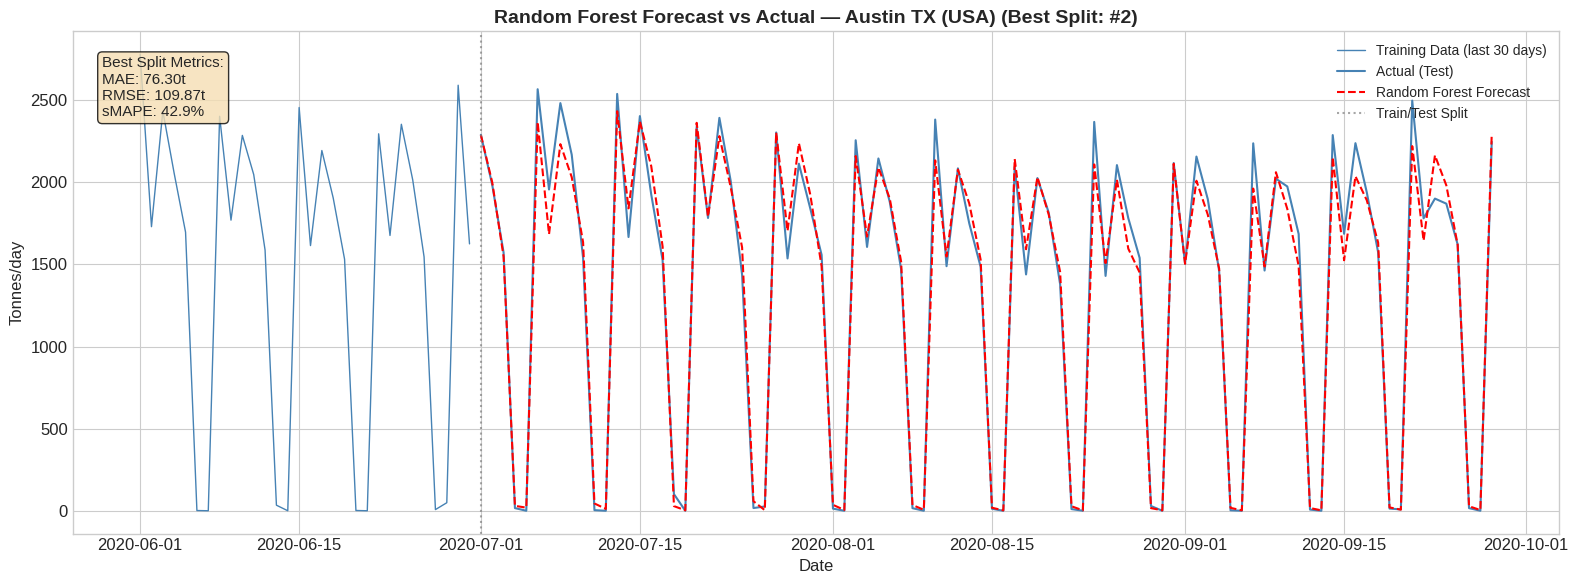

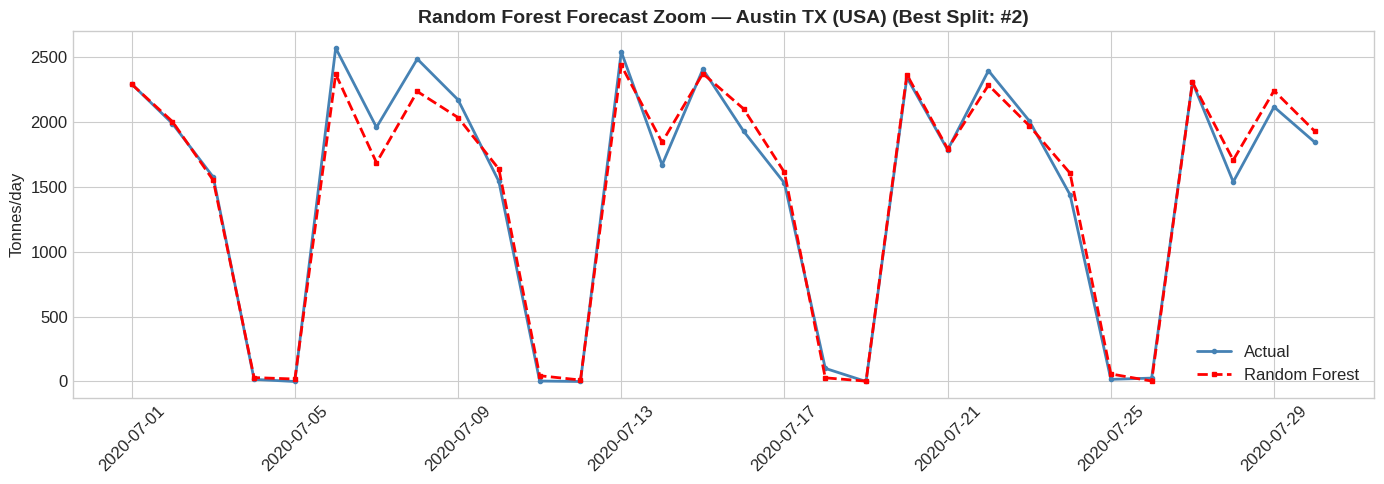

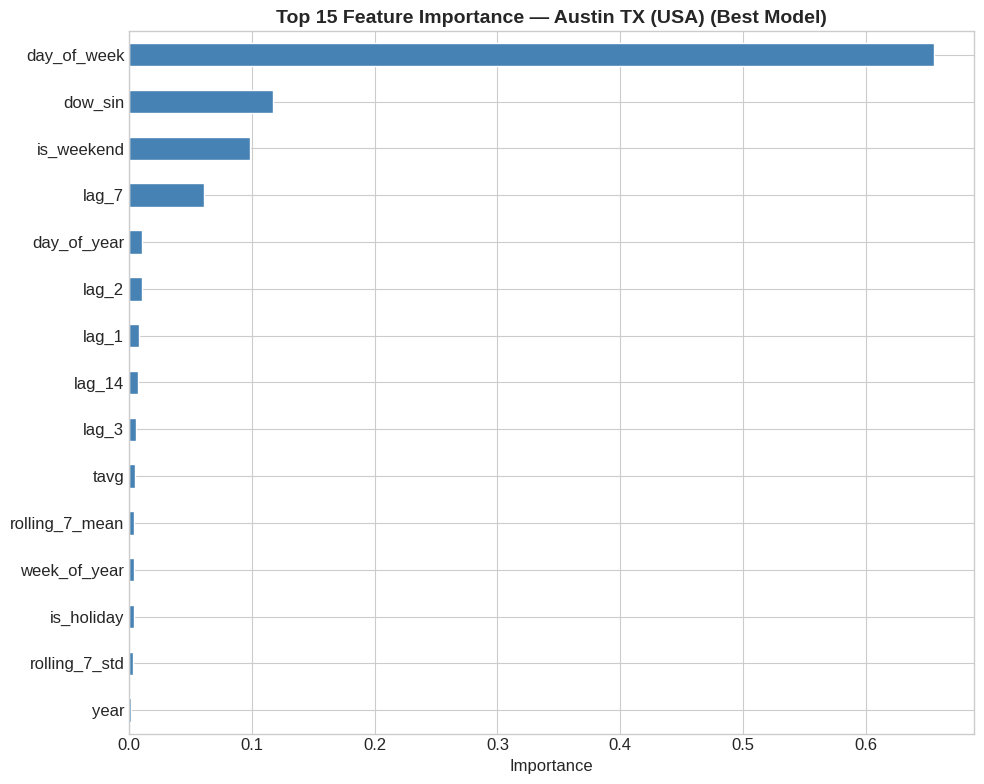


Random Forest PREDICTION — Ballarat (Australia)
Total rows: 4717, Valid (non-NaN in target & features): 4648

Rolling-origin validation: 3 splits of 90 days each

--- Split 1/3 ---
Train: 4378 days (2001-02-01 → 2013-03-25)
Test:  90 days (2013-03-26 → 2013-06-23)
MAE: 7.55t | RMSE: 14.47t | sMAPE: 26.35%

--- Split 2/3 ---
Train: 4468 days (2001-02-01 → 2013-06-23)
Test:  90 days (2013-06-24 → 2013-09-25)
MAE: 6.16t | RMSE: 10.79t | sMAPE: 22.80%

--- Split 3/3 ---
Train: 4558 days (2001-02-01 → 2013-09-25)
Test:  90 days (2013-09-26 → 2013-12-31)
MAE: 7.31t | RMSE: 9.90t | sMAPE: 48.23%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   7.01 tonnes
RMSE:  11.72 tonnes
sMAPE: 32.46%
Best split was Split 2 (sMAPE: 22.80%)


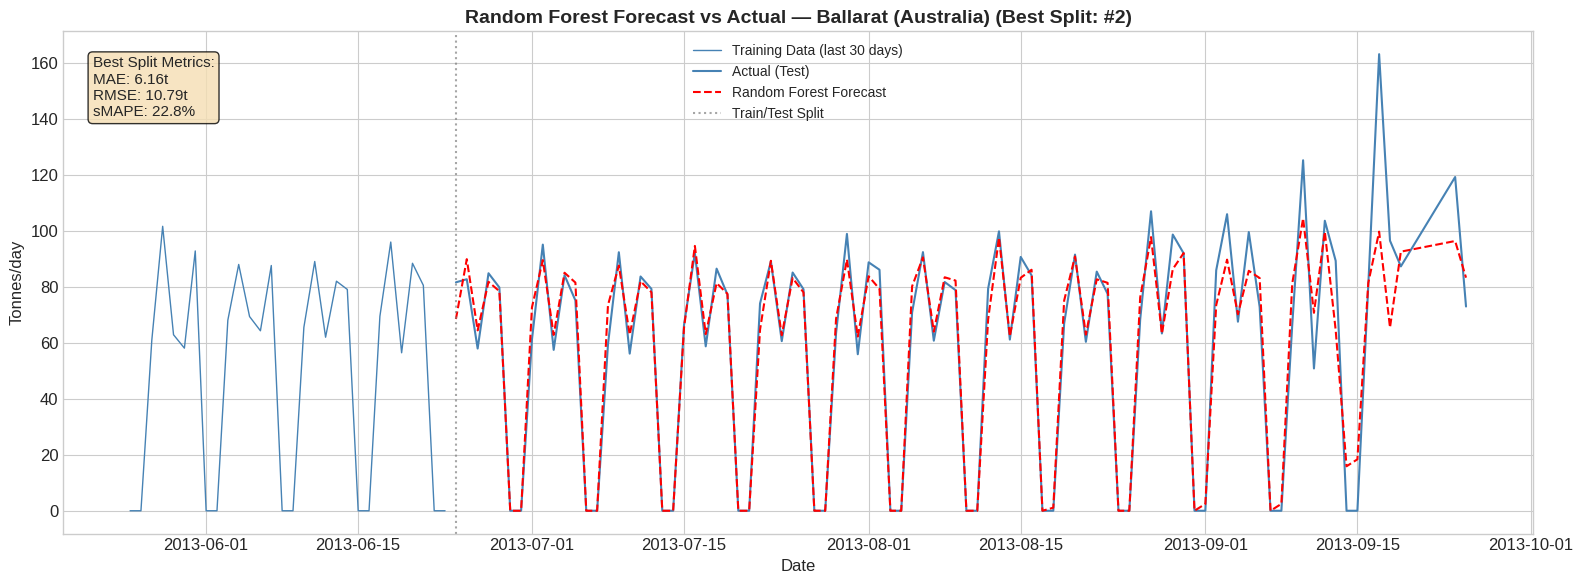

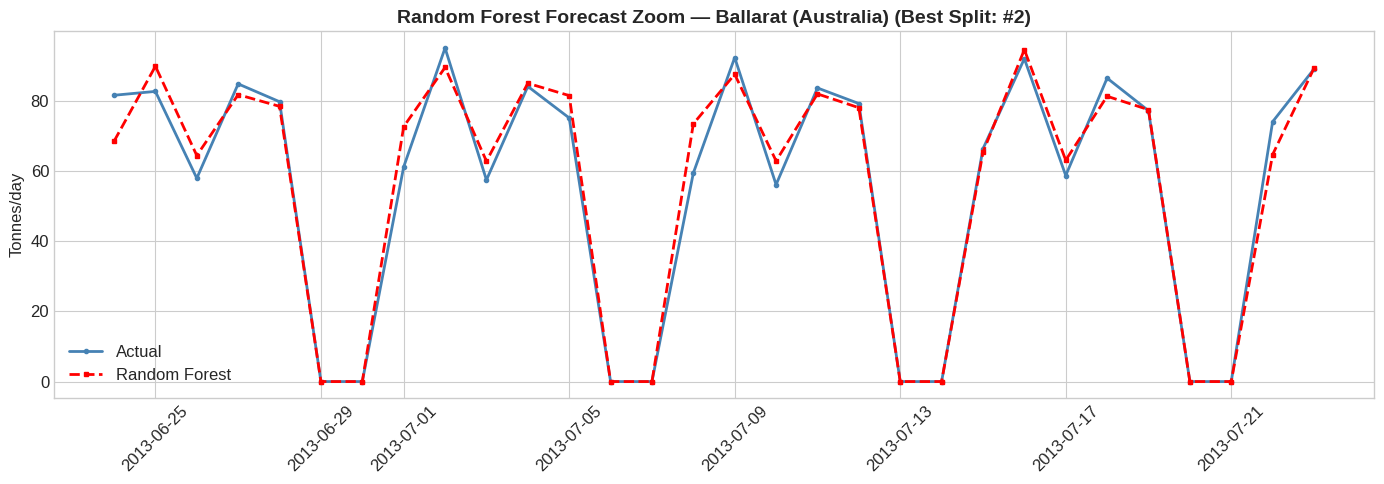

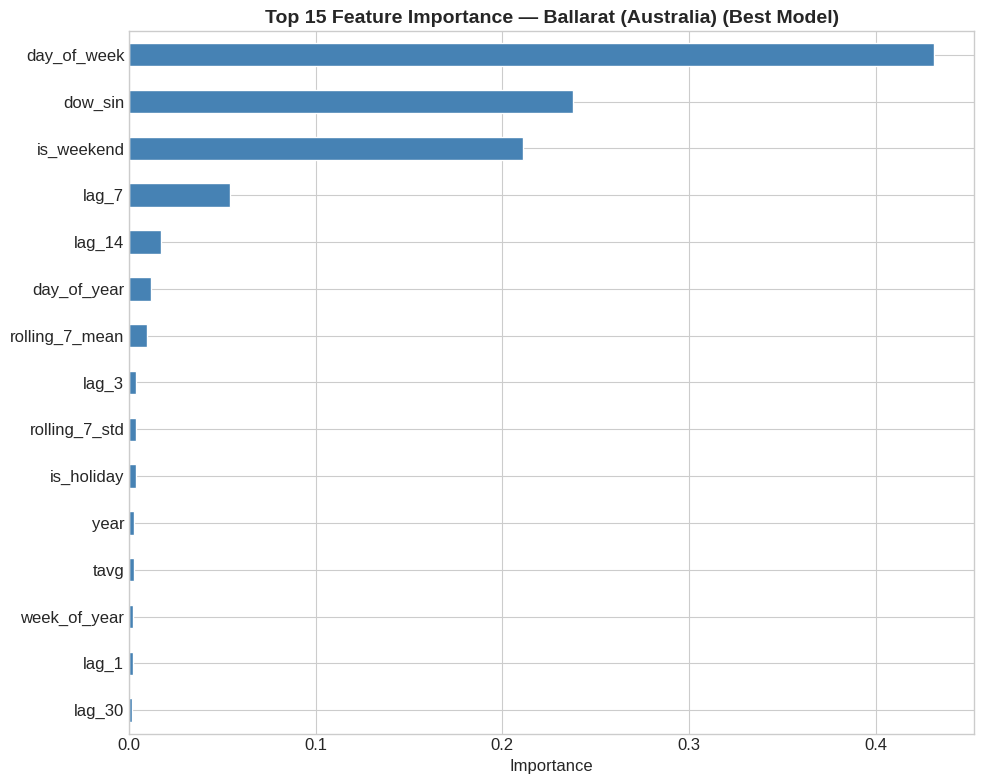

In [9]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_rf_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            split_days = 90,
            n_splits = 3,
            VIS_DIR = VIS_DIR
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [10]:
print("\n" + "=" * 100)
print("Random Forest RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\nValidation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
print(f"Metrics are AVERAGED across splits.")
print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}%")

# average
print("-" * 65)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}%")

# per-split detail
print(f"\n--- Per-split details ---")
for _, row in results_df.iterrows():
    print(f"\n{row['dataset']}:")
    for j, s in enumerate(row['split_details']):
        print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'rf_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/rf_results.csv")


Random Forest RESULTS SUMMARY — ALL DATASETS

Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits.

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%)
-----------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     6.37 |      8.39 |    25.22%
Dehiwala MC (Sri Lanka)        |    28.32 |     38.99 |    22.29%
Homagama PS (Sri Lanka)        |    11.11 |     14.34 |    33.69%
Moratuwa MC (Sri Lanka)        |    16.97 |     22.51 |    24.88%
Austin TX (USA)                |   124.97 |    219.32 |    45.48%
Ballarat (Australia)           |     7.01 |     11.72 |    32.46%
-----------------------------------------------------------------
AVERAGE                        |    32.46 |     52.55 |    30.67%

--- Per-split details ---

Boralesgamuwa UC (Sri Lanka):
  Split 1: MAE=6.45t, RMSE=8.09t, sMAPE=25.62%
  Split 2: MAE=6.35t, RMSE=8.49t, sMAPE=25.28%
  Split 3: MAE=6.30t, RMSE=8.60t, sMAPE=24.76%

Dehi

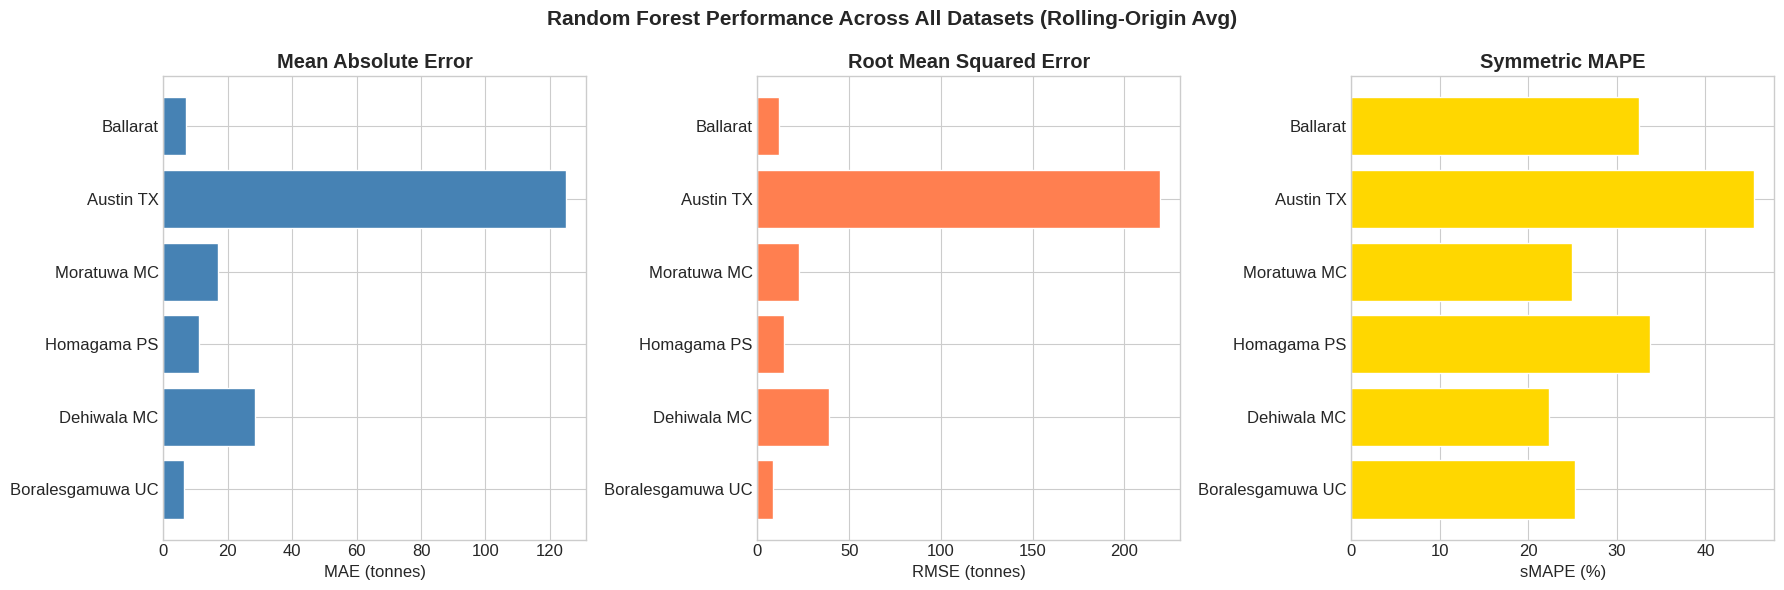

In [11]:
# --- Plot 401: Random Forest Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# sMAPE
axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('Random Forest Performance Across All Datasets (Rolling-Origin Avg)', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '401_rf_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()